# Introduction

Computing persistent homology on a large point cloud can be expensive. Multiple subsampling replaces this computation with persistence diagrams from several smaller subsets and then averages their representations. This method was studied for persistence landscapes by [Chazal et al.](https://proceedings.mlr.press/v37/chazal15.html). For a broader theoretical treatment, including persistence diagrams and persistence measures, see [Approximating Persistent Homology for Large Datasets](https://arxiv.org/abs/2204.09155).

This tutorial has two sections:

1. Multiple subsampling using mean persistence measures, Fréchet means, and mean persistence images.
2. PH approximation on a massive point cloud.

We use [GUDHI](https://gudhi.inria.fr) for persistent homology and persistence representations, and [POT](https://pythonot.github.io) through GUDHI for the Fréchet mean.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from plyfile import PlyData
from gudhi.representations import PersistenceImage
from gudhi.wasserstein.barycenter import lagrangian_barycenter as bary
import ApproxPH

np.random.seed(20211121)

## Comparison of different representations of PH

In this section, we compare the approximation error of mean persistence measures, Fréchet means of persistence diagrams, and mean persistence images on a synthetic dataset sampled from an anulus. The basic pipeline is: (1) draw $B$ independent subsets of $n$ points from the same point cloud; (2) compute their $H_1$ persistence diagrams $D_1,\ldots,D_B$; (3) compute their "means", specifically,

- **Mean persistence measure (MPM):** view each $D_i$ as a discrete measure, compute $\bar{D}=1/B\sum D_i$;
- **Fréchet mean (FM):** the Wasserstein barycenter of $D_i$'s;
- **Mean persistence image:** transform each $D_i$ into persistence image $I_i$, and compute $\bar{I}=1/B\sum I_i$.

In [2]:
def compute_mean(original_set, nb_subs, nb_sub_points, max_edge_length, min_persistence):
    subs = ApproxPH.get_subsample(original_set, nb_sub_points, nb_subs)
    diags = []
    for points in subs:
        diag = ApproxPH.get_PD(points, max_edge_length=max_edge_length,
                              min_persistence=min_persistence)
        diag[np.isposinf(diag[:, 1]), 1] = max_edge_length
        diags.append(diag[diag[:, 1] > diag[:, 0]])

    mean_mesr, mean_mesr_vis = ApproxPH.diag_to_mesr(np.concatenate(diags), 1 / nb_subs)
    wmean = bary(diags, init=0)
    image = PersistenceImage(bandwidth=0.02, weight=lambda point: point[1],
                             resolution=[50, 50],
                             im_range=[0, max_edge_length, 0, max_edge_length])
    mean_image = image.fit_transform(diags).mean(axis=0).reshape(50, 50)
    return mean_mesr, mean_mesr_vis, wmean, mean_image


def plot_means(mean_mesr_vis, wmean, mean_image, cutoff):
    fig, axes = plt.subplots(1, 3, figsize=(13, 4), constrained_layout=True)
    measure_plot = axes[0].imshow(mean_mesr_vis.T, origin='lower', extent=[-ApproxPH.unit / 2, 1 - ApproxPH.unit / 2] * 2,
                                  cmap='hot_r', interpolation='nearest')
    fig.colorbar(measure_plot, ax=axes[0], shrink=0.7, label='Mass per grid cell')
    axes[1].scatter(wmean[:, 0], wmean[:, 1], s=30, color='tab:red')
    image_plot = axes[2].imshow(mean_image, origin='lower', extent=[0, cutoff, 0, cutoff],
                                cmap='hot_r', interpolation='nearest')
    fig.colorbar(image_plot, ax=axes[2], shrink=0.7, label='Image value')
    for ax, title in zip(axes, ['Mean persistence measure', 'Fréchet mean', 'Mean persistence image']):
        ax.set(xlim=(0, cutoff + ApproxPH.unit), ylim=(0, cutoff + ApproxPH.unit), xlabel='Birth', title=title)
        ax.set_aspect('equal')
    for ax in axes[:2]:
        ax.plot([0, cutoff], [0, cutoff], color='0.6', linewidth=0.7)
        ax.set_ylabel('Death')
    axes[2].set_ylabel('Persistence (death − birth)')
    plt.show()

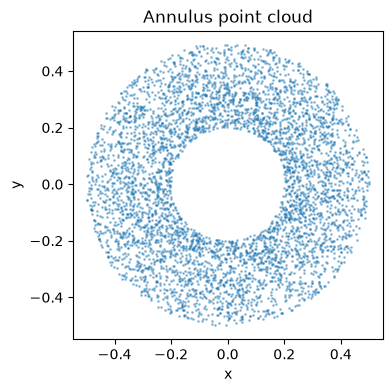

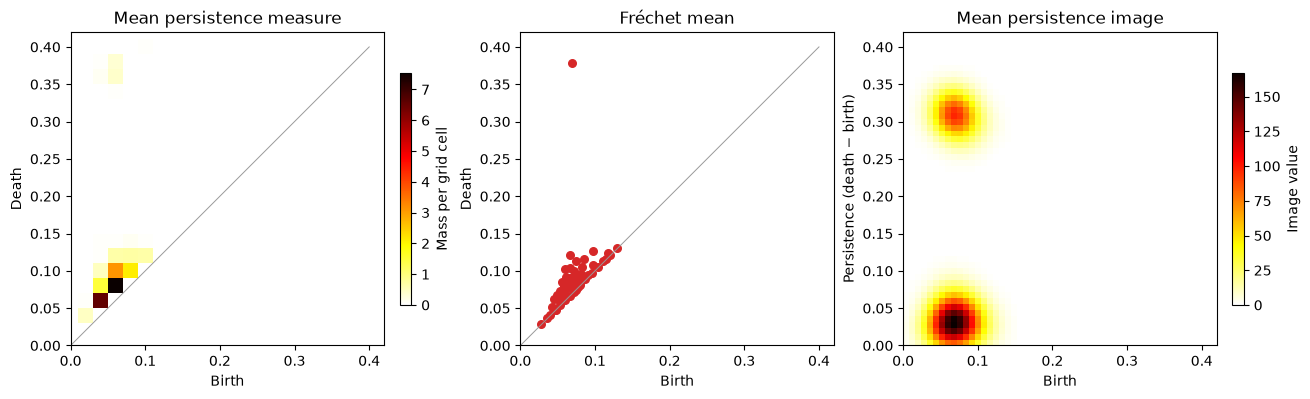

In [3]:
annulus = ApproxPH.sample_annulus(5000, r1=0.2, r2=0.5)
fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(annulus[:, 0], annulus[:, 1], s=1, alpha=0.4)
ax.set(aspect='equal', title='Annulus point cloud', xlabel='x', ylabel='y')
plt.show()

mean_mesr, mean_mesr_vis, wmean, mean_image = compute_mean(
    annulus, nb_subs=20, nb_sub_points=300, max_edge_length=0.4, min_persistence=0.01)
plot_means(mean_mesr_vis, wmean, mean_image, cutoff=0.4)

## PH approximation of a massive point cloud

In this section, we compute the mean PH for real large data. We collect two point clouds from the shape repository held by [AIM@SHAPE project](http://visionair.ge.imati.cnr.it/ontologies/shapes/). The model IDs are 372-Grayloc_-_Smooth_and_watertight_version (with 460592 vertices), and 378-knot_with_stars (with 478704 vertices).

In [5]:
# read point cloud data

import numpy as np
from plyfile import *

pltdata = PlyData.read('data/grayloc.ply')
# pltdata = PlyData.read('data/knot.ply')

x = pltdata['vertex']['x']
y = pltdata['vertex']['y']
z = pltdata['vertex']['z']

large_points = ApproxPH.rescale_points(np.array([x,y,z]).T)
print(large_points.shape)

(460592, 3)


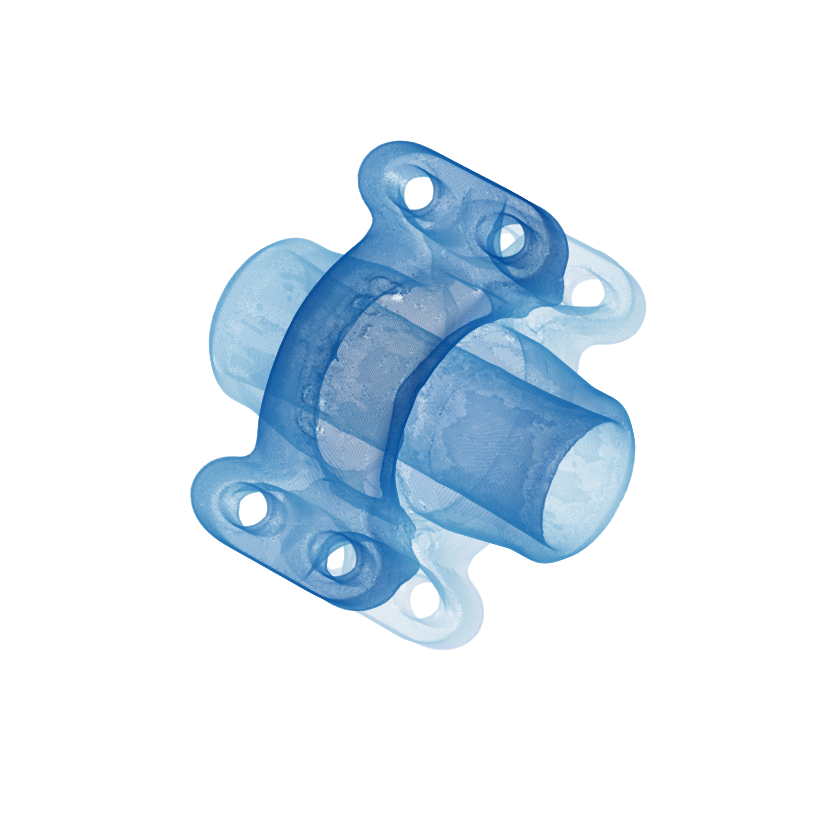

In [6]:
# view point cloud

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize = (8,8))
ax = Axes3D(fig, auto_add_to_figure=False)
fig.add_axes(ax)
ax.scatter(x, y, z, s = 0.05, c=z, alpha=0.7, cmap = 'Blues')
ax.view_init(elev=85., azim=30)
ax.axis('off')
plt.show()

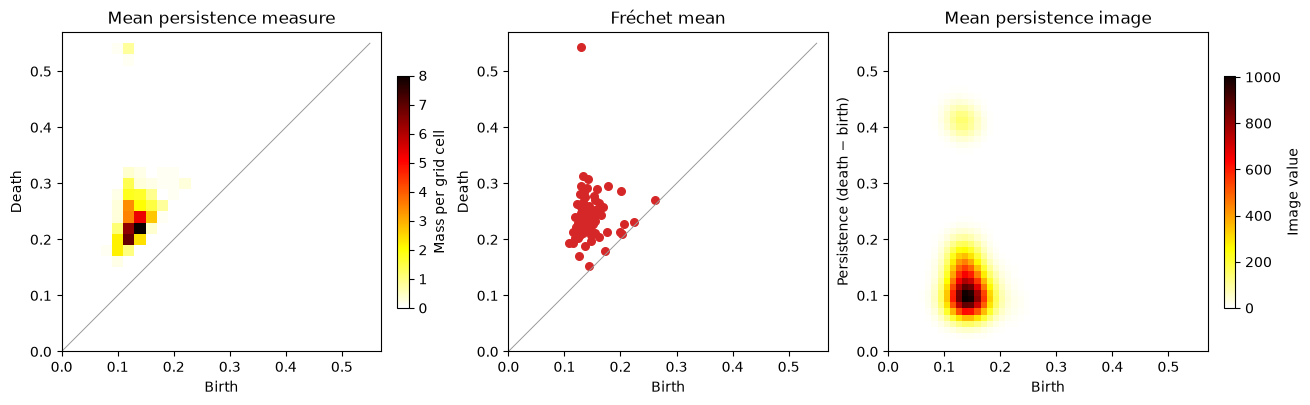

In [7]:
mean_mesr, mean_mesr_vis, wmean, mean_image = compute_mean(
    large_points, nb_subs=10, nb_sub_points=1500, max_edge_length=0.55, min_persistence=0.07)
plot_means(mean_mesr_vis, wmean, mean_image, cutoff=0.55)